In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from PIL import Image

### Load Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

### Preprocessing

In [4]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### Class Labels

In [5]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

### CNN Model

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

C:\Users\diyas\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [7]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train Model

In [8]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.3928 - loss: 1.6456 - val_accuracy: 0.5427 - val_loss: 1.2748
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5513 - loss: 1.2651 - val_accuracy: 0.6122 - val_loss: 1.1008
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6098 - loss: 1.1117 - val_accuracy: 0.6279 - val_loss: 1.0521
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6472 - loss: 1.0146 - val_accuracy: 0.6772 - val_loss: 0.9263
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6773 - loss: 0.9286 - val_accuracy: 0.6715 - val_loss: 0.9368
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6950 - loss: 0.8778 - val_accuracy: 0.6931 - val_loss: 0.8646
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7121 - loss: 0.8278 - val_accuracy: 0.6956 - val_loss: 0.8784
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7299 -

### Evaluate Model

In [9]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7246 - loss: 0.8186


[0.8185905814170837, 0.7246000170707703]

### Test Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Predicted: cat


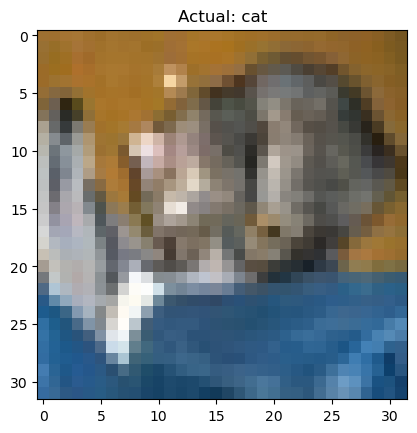

In [10]:
plt.imshow(x_test[0])
plt.title("Actual: " + class_names[np.argmax(y_test[0])])

prediction = model.predict(x_test[0].reshape(1,32,32,3))
print("Predicted:", class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted: cat


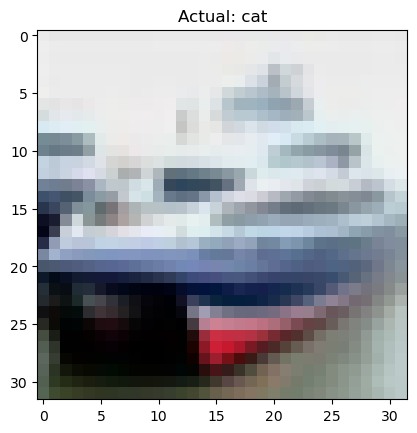

In [12]:
plt.imshow(x_test[1])
plt.title("Actual: " + class_names[np.argmax(y_test[0])])

prediction = model.predict(x_test[0].reshape(1,32,32,3))
print("Predicted:", class_names[np.argmax(prediction)])

# ---- Custom Image Prediction (USER INPUT STYLE) ----

def predict_custom_image(image_path):
    # Load image
    img = Image.open(image_path)
    img = img.resize((32, 32))

    # Convert to array
    img_array = np.array(img)

    # Normalize
    img_array = img_array / 255.0

    # Reshape
    img_array = img_array.reshape(1, 32, 32, 3)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    # Display
    plt.imshow(img_array[0])
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.axis('off')
    plt.show()

    return class_names[predicted_class]


# ---- Use it like this ----
image_path = input("Enter image path: ").strip()

result = predict_custom_image(image_path)

print("Predicted Class:", result)